In [ ]:
# ==============================================================================
# CELL 1 — Installs
# ==============================================================================

!pip uninstall numpy gymnasium CityLearn -y -q
!pip install numpy==1.26.4 -q
!pip install gymnasium==0.29.1 -q
!pip install CityLearn --no-deps -q

In [1]:
!pip install stable-baselines3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.5 MB/s eta 0:00:0000:01


In [2]:

# ==============================================================================
# CELL 2 — Imports and configuration
# ==============================================================================

import os
import json
import time
import random
import warnings
import logging
from copy import deepcopy
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import entropy

from citylearn.citylearn import CityLearnEnv
from citylearn.data import DataSet
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
from gymnasium import spaces

warnings.filterwarnings('ignore')
logging.getLogger('citylearn').setLevel(logging.ERROR)

SEED = 42

DATASET_NAME    = 'citylearn_challenge_2023_phase_3_1'
N_ROUNDS        = 20
LOCAL_STEPS     = 1104
WARMUP_ROUNDS   = 2
FEDPROX_MU      = 0.1
TAU             = 0.995
DELTA_K         = 3
EVAL_EVERY      = 3
RESULTS_DIR     = '/kaggle/working/hafedrl_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

SHARED          = 19
PER_BUILDING    = 11
ACTS_PER_BLDG   = 3
PHYSICS_PENALTY = -10.0

print("Config:")
print(f"  Dataset       : {DATASET_NAME}")
print(f"  Rounds        : {N_ROUNDS}")
print(f"  Local steps   : {LOCAL_STEPS}")
print(f"  Warmup rounds : {WARMUP_ROUNDS}")
print(f"  FedProx mu    : {FEDPROX_MU}")
print(f"  TAU           : {TAU}  DELTA_K: {DELTA_K}")
print(f"  Eval every    : {EVAL_EVERY} rounds")

2026-03-26 00:40:22.845803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774485623.028644     126 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774485623.083785     126 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774485623.539416     126 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774485623.539462     126 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774485623.539464     126 computation_placer.cc:177] computation placer alr

Config:
  Dataset       : citylearn_challenge_2023_phase_3_1
  Rounds        : 20
  Local steps   : 1104
  Warmup rounds : 2
  FedProx mu    : 0.1
  TAU           : 0.995  DELTA_K: 3
  Eval every    : 3 rounds


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 
INFO:root:The citylearn_challenge_2023_phase_3_1 dataset DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.5.0 GitHub repository and write to /root/.cache/citylearn/v2.5.0/datasets. Next time DataSet.get_dataset('citylearn_challenge_2023_phase_3_1') is called, it will read from cache unless DataSet.clear_cache is run first.
INFO:root:The PV sizing data DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.5.0 GitHub repository and write to /root/.cache/citylearn/v2.5.0/misc. Next time DataSet.get_pv_sizing_data is called, it will read from cache unless DataSet.clear_cache is run first.
INFO:root:The battery sizing data DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.5.0 GitHub repository and write to /root/.cache/citylearn/v2.5.0/misc. Next time DataSet.get_battery_sizing_data is called, it will 

Dataset   : citylearn_challenge_2023_phase_3_1
Buildings : 6
Timesteps : 2208

Building        Load Mean   Load Std   Load Max  Solar Peak  Battery kWh
-----------------------------------------------------------------
  Building_1        0.612      0.815      7.459       712.9          4.0
  Building_2        0.455      0.665      8.825       712.9          4.0
  Building_3        0.874      0.843      8.475       712.9          3.3
  Building_4        0.885      0.891     11.247       712.9          3.3
  Building_5        0.631      0.561      8.396       712.9          4.0
  Building_6        0.660      0.611      5.853       712.9          3.3

KL Divergence (load distributions):
  Mean : 0.7201
  Max  : 1.8736
  Min  : 0.1901

  -> KL mean=0.720 confirms non-IID distribution across buildings,
     motivating heterogeneity-aware aggregation in HAFedRL.

Load Profile Pearson Correlation Matrix:
                 _1      _2      _3      _4      _5      _6
  Building_1   1.000   0.025 

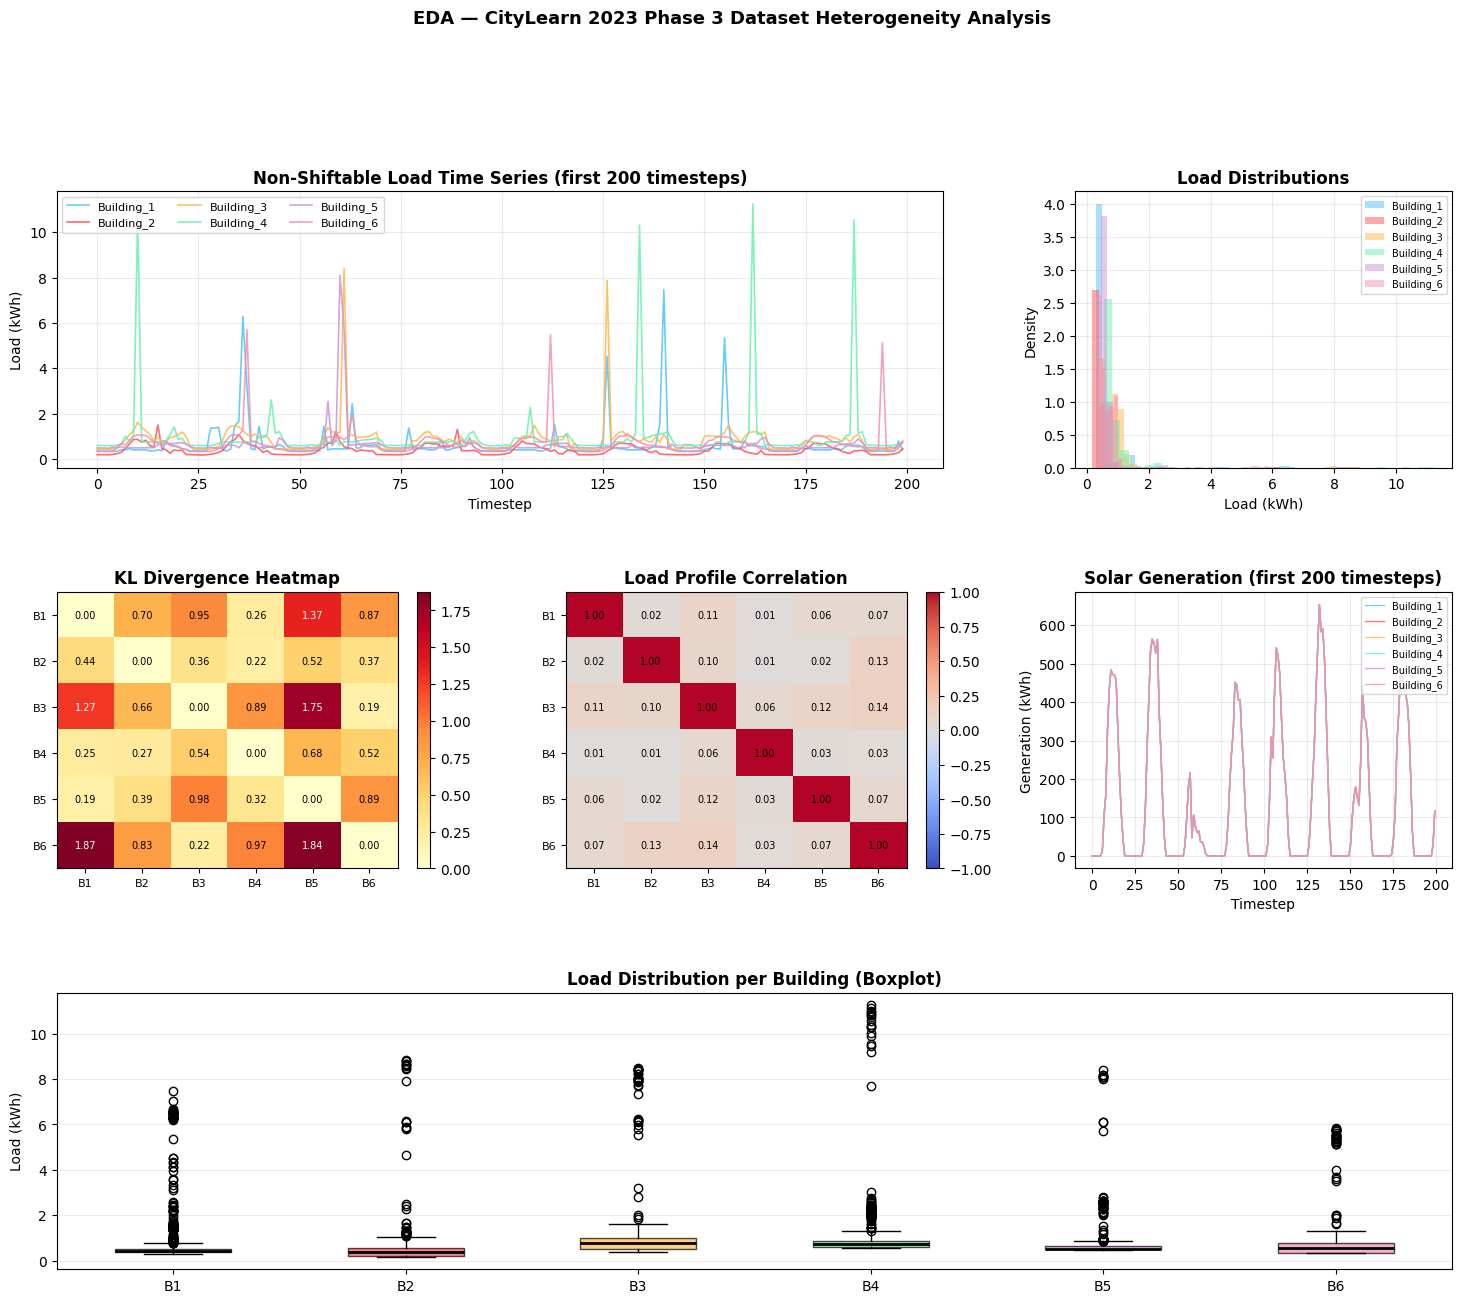

EDA complete. Plot saved.


In [3]:
# ==============================================================================
# CELL 3 — EDA: Dataset heterogeneity analysis
# Justifies why heterogeneity-aware federated learning is needed.
# ==============================================================================

ds          = DataSet()
full_schema = ds.get_schema(DATASET_NAME)
eda_env     = CityLearnEnv(full_schema)

print(f"Dataset   : {DATASET_NAME}")
print(f"Buildings : {len(eda_env.buildings)}")
print(f"Timesteps : {eda_env.time_steps}")
print()

buildings = eda_env.buildings

# --- per-building load statistics ---
print(f"{'Building':<14} {'Load Mean':>10} {'Load Std':>10} {'Load Max':>10} "
      f"{'Solar Peak':>11} {'Battery kWh':>12}")
print("-" * 65)

load_data   = {}
solar_data  = {}
for b in buildings:
    load  = np.array(b.energy_simulation.non_shiftable_load)
    solar = np.array(b.energy_simulation.solar_generation)
    cap   = b.electrical_storage.capacity if b.electrical_storage else 0.0
    load_data[b.name]  = load
    solar_data[b.name] = solar
    print(f"  {b.name:<12} {load.mean():>10.3f} {load.std():>10.3f} "
          f"{load.max():>10.3f} {solar.max():>11.1f} {cap:>12.1f}")

# --- KL divergence matrix ---
def get_hist(data, bins=50):
    hist, _ = np.histogram(data, bins=bins, density=True)
    hist   += 1e-10
    return hist / hist.sum()

names     = [b.name for b in buildings]
n         = len(names)
kl_matrix = np.zeros((n, n))
for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        if i != j:
            kl_matrix[i, j] = entropy(get_hist(load_data[n1]),
                                       get_hist(load_data[n2]))

kl_values = kl_matrix[kl_matrix > 0]
print(f"\nKL Divergence (load distributions):")
print(f"  Mean : {kl_values.mean():.4f}")
print(f"  Max  : {kl_values.max():.4f}")
print(f"  Min  : {kl_values.min():.4f}")
print(f"\n  -> KL mean={kl_values.mean():.3f} confirms non-IID distribution across buildings,")
print(f"     motivating heterogeneity-aware aggregation in HAFedRL.")

# --- Pearson correlation between load profiles ---
print(f"\nLoad Profile Pearson Correlation Matrix:")
loads_arr  = np.stack([load_data[n] for n in names])
corr_matrix = np.corrcoef(loads_arr)
header = "           " + "".join(f"{n[-2:]:>8}" for n in names)
print(header)
for i, n1 in enumerate(names):
    row = f"  {n1:<10}" + "".join(f"{corr_matrix[i,j]:>8.3f}" for j in range(n))
    print(row)

# --- EDA plots ---
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = ['#4FC3F7','#FF5252','#FFB74D','#69F0AE','#CE93D8','#F48FB1']

# Plot 1: load time series per building
ax1 = fig.add_subplot(gs[0, :2])
for i, b in enumerate(buildings):
    ax1.plot(load_data[b.name][:200], color=colors[i],
             label=b.name, linewidth=1.2, alpha=0.85)
ax1.set_title('Non-Shiftable Load Time Series (first 200 timesteps)',
              fontweight='bold')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Load (kWh)')
ax1.legend(ncol=3, fontsize=8)
ax1.grid(True, alpha=0.25)

# Plot 2: load distributions
ax2 = fig.add_subplot(gs[0, 2])
for i, b in enumerate(buildings):
    ax2.hist(load_data[b.name], bins=40, alpha=0.5,
             color=colors[i], label=b.name, density=True)
ax2.set_title('Load Distributions', fontweight='bold')
ax2.set_xlabel('Load (kWh)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.25)

# Plot 3: KL divergence heatmap
ax3 = fig.add_subplot(gs[1, 0])
short_names = [n.replace('Building_', 'B') for n in names]
im = ax3.imshow(kl_matrix, cmap='YlOrRd', aspect='auto')
ax3.set_xticks(range(n))
ax3.set_yticks(range(n))
ax3.set_xticklabels(short_names, fontsize=8)
ax3.set_yticklabels(short_names, fontsize=8)
for i in range(n):
    for j in range(n):
        ax3.text(j, i, f'{kl_matrix[i,j]:.2f}',
                 ha='center', va='center', fontsize=7,
                 color='black' if kl_matrix[i,j] < 1.0 else 'white')
plt.colorbar(im, ax=ax3, fraction=0.046)
ax3.set_title('KL Divergence Heatmap', fontweight='bold')

# Plot 4: correlation heatmap
ax4 = fig.add_subplot(gs[1, 1])
im2 = ax4.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax4.set_xticks(range(n))
ax4.set_yticks(range(n))
ax4.set_xticklabels(short_names, fontsize=8)
ax4.set_yticklabels(short_names, fontsize=8)
for i in range(n):
    for j in range(n):
        ax4.text(j, i, f'{corr_matrix[i,j]:.2f}',
                 ha='center', va='center', fontsize=7)
plt.colorbar(im2, ax=ax4, fraction=0.046)
ax4.set_title('Load Profile Correlation', fontweight='bold')

# Plot 5: solar generation
ax5 = fig.add_subplot(gs[1, 2])
for i, b in enumerate(buildings):
    ax5.plot(solar_data[b.name][:200], color=colors[i],
             label=b.name, linewidth=1.0, alpha=0.8)
ax5.set_title('Solar Generation (first 200 timesteps)', fontweight='bold')
ax5.set_xlabel('Timestep')
ax5.set_ylabel('Generation (kWh)')
ax5.legend(fontsize=7)
ax5.grid(True, alpha=0.25)

# Plot 6: per-building load boxplots
ax6 = fig.add_subplot(gs[2, :])
bp = ax6.boxplot(
    [load_data[b.name] for b in buildings],
    labels=[b.name.replace('Building_', 'B') for b in buildings],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax6.set_title('Load Distribution per Building (Boxplot)', fontweight='bold')
ax6.set_ylabel('Load (kWh)')
ax6.grid(True, alpha=0.25, axis='y')

plt.suptitle('EDA — CityLearn 2023 Phase 3 Dataset Heterogeneity Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(os.path.join(RESULTS_DIR, 'eda_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("EDA complete. Plot saved.")

In [4]:
# ==============================================================================
# CELL 4 — Environment wrapper with eval_mode flag
# ==============================================================================

def make_single_building_schema(full_schema, building_index):
    schema     = deepcopy(full_schema)
    all_keys   = list(schema['buildings'].keys())
    target_key = all_keys[building_index]
    schema['buildings'] = {target_key: schema['buildings'][target_key]}
    return schema


class CityLearnSingleBuildingEnv(gym.Env):
    def __init__(self, full_schema, building_index):
        super().__init__()
        self.full_schema    = full_schema
        self.building_index = building_index
        self.single_schema  = make_single_building_schema(full_schema, building_index)
        self.eval_mode      = False
        self._make_env()

    def _make_env(self):
        self.env  = CityLearnEnv(deepcopy(self.single_schema))
        raw_reset = self.env.reset()
        obs_b     = self._extract_obs(raw_reset)

        building          = self.env.buildings[0]
        self.action_names = [k for k, v in building.action_metadata.items() if v]
        assert len(self.action_names) == ACTS_PER_BLDG, (
            f"Expected {ACTS_PER_BLDG} active actions, "
            f"got {len(self.action_names)}: {self.action_names}"
        )
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=obs_b.shape, dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(ACTS_PER_BLDG,), dtype=np.float32
        )
        self._last_obs = obs_b

    def _extract_obs(self, raw):
        if isinstance(raw, tuple):
            raw = raw[0]
        if isinstance(raw, list) and len(raw) == 1 and isinstance(raw[0], list):
            raw = raw[0]
        return np.array(raw, dtype=np.float32)

    def reset(self, seed=None, options=None):
        if self.eval_mode:
            # full CityLearnEnv rebuild guarantees episode cursor at timestep 0
            self.env = CityLearnEnv(deepcopy(self.single_schema))
        raw            = self.env.reset()
        obs            = self._extract_obs(raw)
        self._last_obs = obs
        return obs, {}

    def step(self, action):
        action = np.clip(action, -1.0, 1.0)
        try:
            # record net electricity before action
            building     = self.env.buildings[0]
            load_before  = float(building.energy_simulation.non_shiftable_load[
                self.env.time_step
            ])
    
            result                    = self.env.step([action.tolist()])
            obs, rewards, done, *rest = result
            obs_b                     = self._extract_obs(obs)
    
            # net electricity consumption after action
            net_elec = float(building.net_electricity_consumption[-1])
    
            # reward = reduction in net consumption vs non-shiftable load
            # positive when storage/cooling reduces grid draw below base load
            reward_b = load_before - net_elec
    
            if isinstance(done, (list, tuple, np.ndarray)):
                done_b = bool(done[0])
            else:
                done_b = bool(done)
    
            self._last_obs = obs_b
    
        except AssertionError:
            obs_b    = self._last_obs
            reward_b = PHYSICS_PENALTY
            done_b   = not self.eval_mode
    
        return obs_b, reward_b, done_b, False, {}


def make_envs(full_schema, n_buildings):
    envs = []
    for i in range(n_buildings):
        envs.append(
            DummyVecEnv([lambda i=i: CityLearnSingleBuildingEnv(full_schema, i)])
        )
    return envs


full_schema = ds.get_schema(DATASET_NAME)
env0        = CityLearnEnv(full_schema)
N_BUILDINGS = len(env0.buildings)

print(f"Buildings : {N_BUILDINGS}")
print(f"\nActive action names per building:")
for i in range(N_BUILDINGS):
    s     = make_single_building_schema(full_schema, i)
    e     = CityLearnEnv(s)
    b     = e.buildings[0]
    names = [k for k, v in b.action_metadata.items() if v]
    print(f"  Building_{i+1}: {names}")

t        = time.time()
_te      = CityLearnSingleBuildingEnv(full_schema, 0)
_te.reset()
t_first  = time.time() - t
t        = time.time()
_te.reset()
t_second = time.time() - t
print(f"\nReset timing: first={t_first:.3f}s  subsequent={t_second:.4f}s")

envs = make_envs(full_schema, N_BUILDINGS)
print("Environment wrappers created.")

INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 


Buildings : 6

Active action names per building:
  Building_1: ['dhw_storage', 'electrical_storage', 'cooling_device']
  Building_2: ['dhw_storage', 'electrical_storage', 'cooling_device']
  Building_3: ['dhw_storage', 'electrical_storage', 'cooling_device']
  Building_4: ['dhw_storage', 'electrical_storage', 'cooling_device']
  Building_5: ['dhw_storage', 'electrical_storage', 'cooling_device']
  Building_6: ['dhw_storage', 'electrical_storage', 'cooling_device']

Reset timing: first=1.501s  subsequent=0.0062s
Environment wrappers created.


In [5]:
# ==============================================================================
# CELL 5 — Utility functions
# ==============================================================================

def get_flat_params(model):
    return {k: v.cpu().clone() for k, v in model.policy.state_dict().items()}


def set_flat_params(model, params):
    model.policy.load_state_dict(
        {k: v.to(model.device) for k, v in params.items()}
    )


def params_to_vector(params):
    return torch.cat([v.flatten().float() for v in params.values()])


def vector_to_params(vec, reference_params):
    result = {}
    idx    = 0
    for k, v in reference_params.items():
        size      = v.numel()
        result[k] = vec[idx : idx + size].reshape(v.shape).to(v.dtype)
        idx       += size
    return result


def average_params(param_list, weights=None):
    if weights is None:
        weights = [1.0 / len(param_list)] * len(param_list)
    w = np.array(weights, dtype=np.float64)
    w = w / w.sum()
    averaged = {}
    for key in param_list[0].keys():
        stacked  = torch.stack([p[key].float() for p in param_list])
        w_tensor = torch.tensor(w, dtype=torch.float32)
        while w_tensor.dim() < stacked.dim():
            w_tensor = w_tensor.unsqueeze(-1)
        averaged[key] = (stacked * w_tensor).sum(dim=0).to(param_list[0][key].dtype)
    return averaged


# algo_seed offsets ensure each algorithm starts from a different random state
# so agents within each algorithm also diverge from each other before aggregation
ALGO_SEED_OFFSETS = {
    'nonfed'  : 0,
    'fedavg'  : 100,
    'fedprox' : 200,
    'hafedrl' : 300,
}

def make_agents(envs, algo='nonfed'):
    agents = []
    offset = ALGO_SEED_OFFSETS.get(algo, 0)
    for i, env in enumerate(envs):
        # each building agent gets a unique seed: algo offset + building index
        agent_seed = offset + i
        agent = PPO(
            'MlpPolicy',
            env,
            n_steps       = 1104,
            batch_size    = 64,
            n_epochs      = 5,
            learning_rate = 3e-4,
            gamma         = 0.99,
            verbose       = 0,
            seed          = agent_seed,
        )
        agents.append(agent)
    return agents


def compute_zero_action_baselines(full_schema, n_buildings):
    baselines = []
    for i in range(n_buildings):
        env = CityLearnSingleBuildingEnv(full_schema, i)
        env.eval_mode = True
        obs, _ = env.reset()
        total  = 0.0
        done   = False
        steps  = 0
        while not done and steps < 2208:
            obs, reward, done, _, _ = env.step(
                np.zeros(ACTS_PER_BLDG, dtype=np.float32)
            )
            total += reward
            steps += 1
        baselines.append(total)
        print(f"  baseline building_{i+1}: {total:.4f} ({steps} steps)")
    return baselines


print("Computing zero-action baselines (runs once)...")
ZERO_ACTION_BASELINES = compute_zero_action_baselines(full_schema, N_BUILDINGS)
print(f"Baselines: {[round(b, 2) for b in ZERO_ACTION_BASELINES]}")


def evaluate_agents(agents):
    """
    Runs a fresh full-episode deterministic rollout per agent.
    Constructs a new CityLearnSingleBuildingEnv so the episode cursor starts
    at timestep 0, independent of the training env state.
    Returns marginal reward = agent_total - zero_action_baseline per agent.
    """
    rewards = []
    for i, agent in enumerate(agents):
        building_idx       = agent.env.envs[0].building_index
        eval_env           = CityLearnSingleBuildingEnv(full_schema, building_idx)
        eval_env.eval_mode = True
        obs, _             = eval_env.reset()

        total = 0.0
        done  = False
        steps = 0
        while not done and steps < 2208:
            obs_vec         = obs.reshape(1, -1)
            action, _       = agent.predict(obs_vec, deterministic=True)
            action_squeezed = action.squeeze(0)
            obs, reward, done, _, _ = eval_env.step(action_squeezed)
            total += reward
            steps += 1

        rewards.append(total - ZERO_ACTION_BASELINES[i])
    return rewards


print("Utility functions defined.")
print("Ready for training.")

Computing zero-action baselines (runs once)...
  baseline building_1: 1350.1747 (2207 steps)
  baseline building_2: 1005.3730 (2207 steps)
  baseline building_3: 1929.1779 (2207 steps)
  baseline building_4: 1953.5276 (2207 steps)
  baseline building_5: 1393.0442 (2207 steps)
  baseline building_6: 1457.7269 (2207 steps)
Baselines: [1350.17, 1005.37, 1929.18, 1953.53, 1393.04, 1457.73]
Utility functions defined.
Ready for training.


In [6]:
# ==============================================================================
# CELL 6 — Training loops
# ==============================================================================

def _log(name, rnd, n_rounds, rewards, t_round, extra=None):
    msg = (
        f"  [{name}] Round {rnd:3d}/{n_rounds} | "
        f"mean_marginal={np.mean(rewards):+.4f} | "
        f"min={np.min(rewards):+.4f} | "
        f"max={np.max(rewards):+.4f} | "
        f"{t_round:.1f}s"
    )
    if extra:
        msg += f" | {extra}"
    print(msg, flush=True)


def _should_eval(rnd):
    return rnd == 1 or rnd % EVAL_EVERY == 0 or rnd == N_ROUNDS


def run_non_federated(envs):
    print("\nRunning: Non-federated PPO")
    agents = make_agents(envs, algo='nonfed')
    log          = defaultdict(list)
    last_rewards = None

    for rnd in range(1, N_ROUNDS + 1):
        t0 = time.time()
        for i, agent in enumerate(agents):
            agent.learn(total_timesteps=LOCAL_STEPS, reset_num_timesteps=True)
            print(f"    agent {i+1}/{N_BUILDINGS}", end='  ', flush=True)
        print()

        if _should_eval(rnd):
            last_rewards = evaluate_agents(agents)
        rewards = last_rewards

        t_round = time.time() - t0
        log['round'].append(rnd)
        log['mean_reward'].append(float(np.mean(rewards)))
        log['rewards'].append([float(r) for r in rewards])
        _log("NonFed", rnd, N_ROUNDS, rewards, t_round)

    return agents, log


def run_fedavg(envs):
    print("\nRunning: FedAvg + PPO")
    agents = make_agents(envs, algo='fedavg')
    log          = defaultdict(list)
    last_rewards = None

    for rnd in range(1, N_ROUNDS + 1):
        t0 = time.time()
        for i, agent in enumerate(agents):
            agent.learn(total_timesteps=LOCAL_STEPS, reset_num_timesteps=True)
            print(f"    agent {i+1}/{N_BUILDINGS}", end='  ', flush=True)
        print()

        params_list   = [get_flat_params(a) for a in agents]
        global_params = average_params(params_list)
        for agent in agents:
            set_flat_params(agent, global_params)

        if _should_eval(rnd):
            last_rewards = evaluate_agents(agents)
        rewards = last_rewards

        t_round = time.time() - t0
        log['round'].append(rnd)
        log['mean_reward'].append(float(np.mean(rewards)))
        log['rewards'].append([float(r) for r in rewards])
        _log("FedAvg", rnd, N_ROUNDS, rewards, t_round)

    return agents, log


def run_fedprox(envs):
    print("\nRunning: FedProx + PPO")
    agents = make_agents(envs, algo='fedprox')
    log           = defaultdict(list)
    global_params = get_flat_params(agents[0])
    last_rewards  = None

    for rnd in range(1, N_ROUNDS + 1):
        t0         = time.time()
        global_vec = params_to_vector(global_params)

        for i, agent in enumerate(agents):
            agent.learn(total_timesteps=LOCAL_STEPS, reset_num_timesteps=True)
            after  = get_flat_params(agent)
            prox_v = params_to_vector(after) - FEDPROX_MU * (params_to_vector(after) - global_vec)
            set_flat_params(agent, vector_to_params(prox_v, after))
            print(f"    agent {i+1}/{N_BUILDINGS}", end='  ', flush=True)
        print()

        params_list   = [get_flat_params(a) for a in agents]
        global_params = average_params(params_list)
        for agent in agents:
            set_flat_params(agent, global_params)

        if _should_eval(rnd):
            last_rewards = evaluate_agents(agents)
        rewards = last_rewards

        t_round = time.time() - t0
        log['round'].append(rnd)
        log['mean_reward'].append(float(np.mean(rewards)))
        log['rewards'].append([float(r) for r in rewards])
        _log("FedProx", rnd, N_ROUNDS, rewards, t_round)

    return agents, log


def compute_heterogeneity_weights(agents, global_params):
    global_vec = params_to_vector(global_params)
    weights    = []
    for agent in agents:
        local_vec = params_to_vector(get_flat_params(agent))
        cos_sim   = torch.nn.functional.cosine_similarity(
            local_vec.unsqueeze(0), global_vec.unsqueeze(0)
        ).item()
        weights.append(0.25 + 0.75 * max(0.0, cos_sim))
    return weights


def run_hafedrl(envs):
    print("\nRunning: HAFedRL")
    agents = make_agents(envs, algo='hafedrl')
    log           = defaultdict(list)
    global_params = get_flat_params(agents[0])
    extra_steps   = [0] * N_BUILDINGS
    last_rewards  = None

    for rnd in range(1, N_ROUNDS + 1):
        t0 = time.time()

        for i, agent in enumerate(agents):
            steps = LOCAL_STEPS * (1 + extra_steps[i])
            agent.learn(total_timesteps=steps, reset_num_timesteps=True)
            print(f"    agent {i+1}/{N_BUILDINGS}({steps}steps)", end='  ', flush=True)
        print()

        if rnd <= WARMUP_ROUNDS:
            params_list   = [get_flat_params(a) for a in agents]
            global_params = average_params(params_list)
            weights       = [1.0] * N_BUILDINGS
        else:
            weights       = compute_heterogeneity_weights(agents, global_params)
            params_list   = [get_flat_params(a) for a in agents]
            global_params = average_params(params_list, weights=weights)
            max_w         = max(weights)
            for i, w in enumerate(weights):
                extra_steps[i] = DELTA_K if (w / max_w) < TAU else 0

        for agent in agents:
            set_flat_params(agent, global_params)

        if _should_eval(rnd):
            last_rewards = evaluate_agents(agents)
        rewards = last_rewards

        t_round = time.time() - t0
        log['round'].append(rnd)
        log['mean_reward'].append(float(np.mean(rewards)))
        log['rewards'].append([float(r) for r in rewards])
        log['weights'].append([float(w) for w in weights])
        _log("HAFedRL", rnd, N_ROUNDS, rewards, t_round,
             extra=f"w={[round(w,3) for w in weights]}")

    return agents, log


print("Training functions defined.")

Training functions defined.


In [7]:
# ==============================================================================
# CELL 7 — Run all experiments
# ==============================================================================

t_total = time.time()

agents_nonfed,  log_nonfed  = run_non_federated(make_envs(full_schema, N_BUILDINGS))
agents_fedavg,  log_fedavg  = run_fedavg(make_envs(full_schema, N_BUILDINGS))
agents_fedprox, log_fedprox = run_fedprox(make_envs(full_schema, N_BUILDINGS))
agents_hafedrl, log_hafedrl = run_hafedrl(make_envs(full_schema, N_BUILDINGS))

print(f"\nTotal training time: {(time.time()-t_total)/60:.1f} minutes")

all_logs = {
    'Non-federated PPO' : log_nonfed,
    'FedAvg'            : log_fedavg,
    'FedProx'           : log_fedprox,
    'HAFedRL'           : log_hafedrl,
}

with open(os.path.join(RESULTS_DIR, 'all_logs.json'), 'w') as f:
    json.dump(
        {
            alg: {
                kk: (
                    [[float(w) for w in row] for row in vv]
                    if kk == 'weights' else
                    [[float(r) for r in row] for row in vv]
                    if kk == 'rewards' else
                    [float(x) for x in vv]
                )
                for kk, vv in v.items()
            }
            for alg, v in all_logs.items()
        },
        f, indent=2
    )

ckpt_dir = os.path.join(RESULTS_DIR, 'checkpoints')
os.makedirs(ckpt_dir, exist_ok=True)
for i, agent in enumerate(agents_hafedrl):
    agent.save(os.path.join(ckpt_dir, f'hafedrl_building_{i+1}'))
for i, agent in enumerate(agents_fedavg):
    agent.save(os.path.join(ckpt_dir, f'fedavg_building_{i+1}'))
for i, agent in enumerate(agents_nonfed):
    agent.save(os.path.join(ckpt_dir, f'nonfed_building_{i+1}'))

print("Results and checkpoints saved.")
print(f"Output dir: {RESULTS_DIR}")


Running: Non-federated PPO
    agent 1/6      agent 2/6      agent 3/6      agent 4/6      agent 5/6      agent 6/6  
  [NonFed] Round   1/20 | mean_marginal=-23370.7563 | min=-23862.5921 | max=-22834.1833 | 65.1s
    agent 1/6      agent 2/6      agent 3/6      agent 4/6      agent 5/6      agent 6/6  
  [NonFed] Round   2/20 | mean_marginal=-23370.7563 | min=-23862.5921 | max=-22834.1833 | 28.9s
    agent 1/6      agent 2/6      agent 3/6      agent 4/6      agent 5/6      agent 6/6  
  [NonFed] Round   3/20 | mean_marginal=-23291.6579 | min=-23819.1819 | max=-22803.6445 | 63.7s
    agent 1/6      agent 2/6      agent 3/6      agent 4/6      agent 5/6      agent 6/6  
  [NonFed] Round   4/20 | mean_marginal=-23291.6579 | min=-23819.1819 | max=-22803.6445 | 29.1s
    agent 1/6      agent 2/6      agent 3/6      agent 4/6      agent 5/6      agent 6/6  
  [NonFed] Round   5/20 | mean_marginal=-23291.6579 | min=-23819.1819 | max=-22803.6445 | 29.4s
    agent 1/6      agent 2/6      age

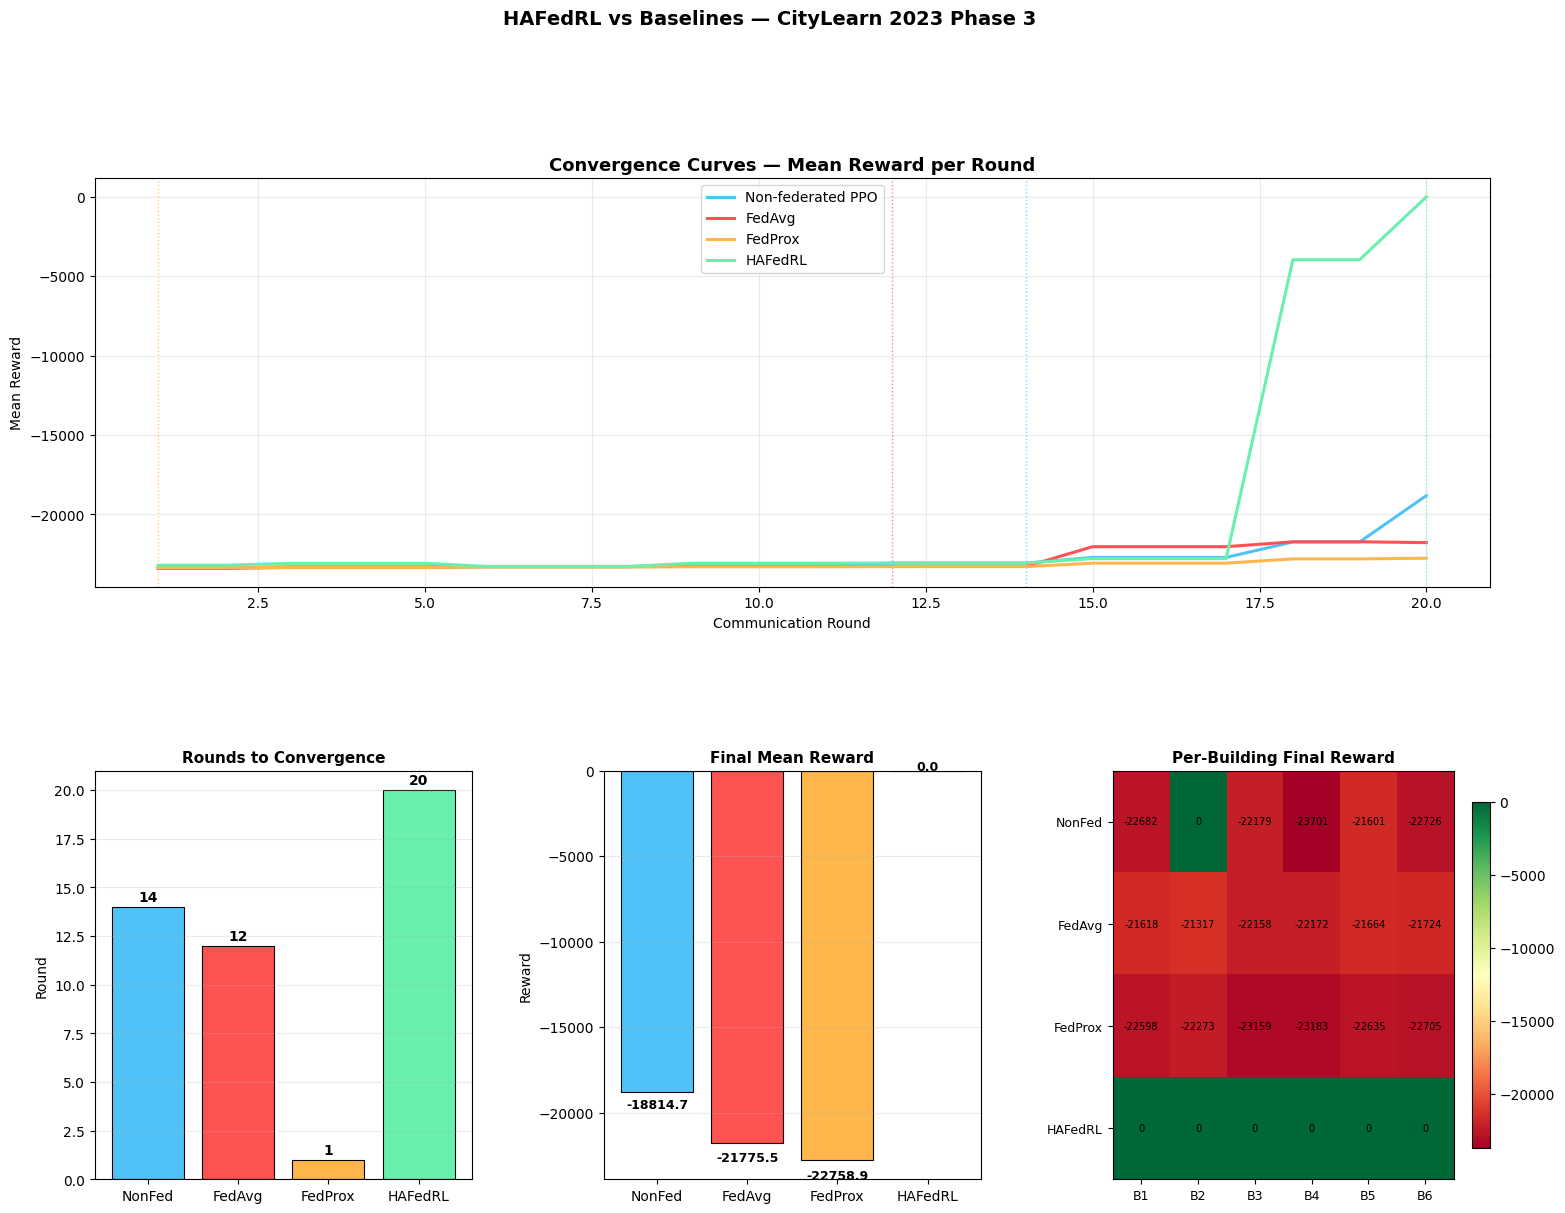

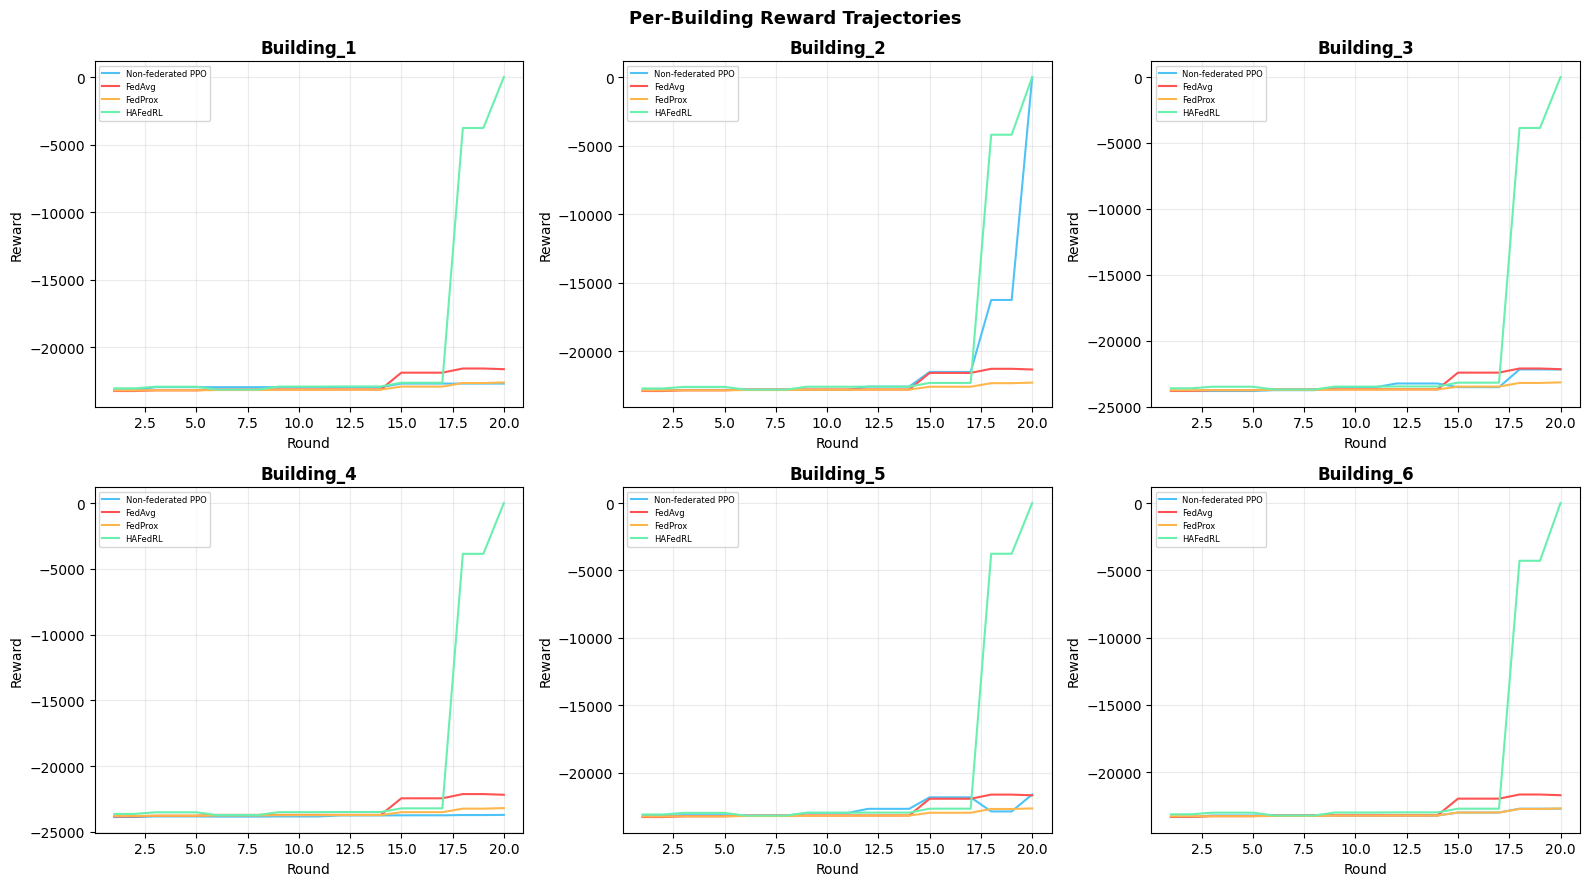

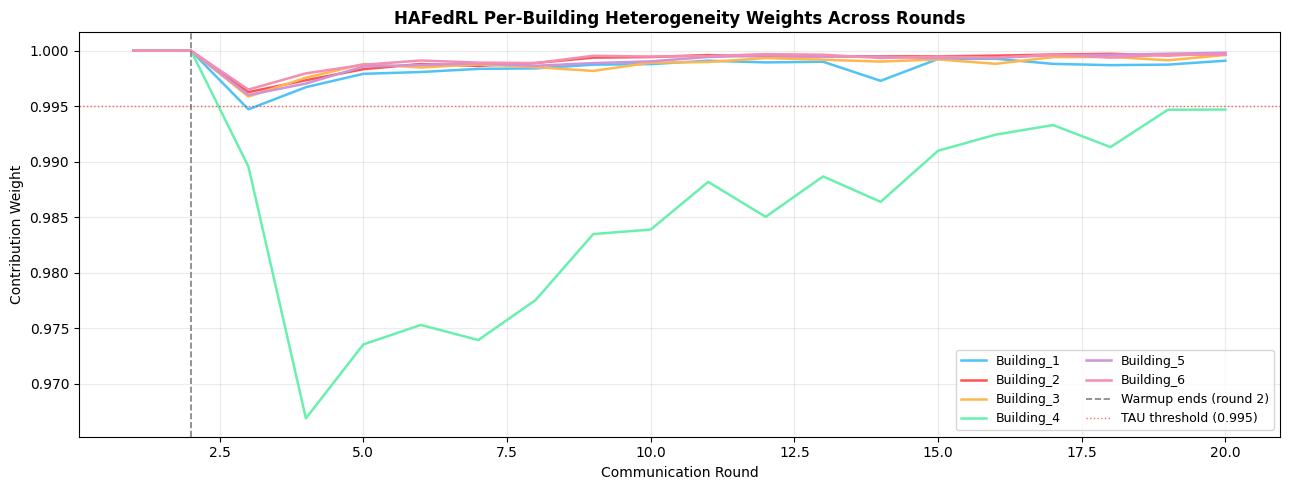

In [8]:
# ==============================================================================
# CELL 8 — Results visualisation + statistical validation
# ==============================================================================

ALGO_COLORS = {
    'Non-federated PPO' : '#4FC3F7',
    'FedAvg'            : '#FF5252',
    'FedProx'           : '#FFB74D',
    'HAFedRL'           : '#69F0AE',
}
ALGO_ORDER = ['Non-federated PPO', 'FedAvg', 'FedProx', 'HAFedRL']


def convergence_round(log, window=5, threshold=0.05):
    rewards = np.array(log['mean_reward'])
    if len(rewards) < window:
        return len(rewards)
    final = rewards[-window:].mean()
    for i in range(len(rewards) - window):
        if abs(rewards[i:i+window].mean() - final) / (abs(final) + 1e-8) < threshold:
            return i + 1
    return len(rewards)


conv_rounds  = {name: convergence_round(all_logs[name]) for name in ALGO_ORDER}
final_rewards = {name: all_logs[name]['mean_reward'][-1] for name in ALGO_ORDER}
final_rewards_per_building = {
    name: np.array(all_logs[name]['rewards'][-1]) for name in ALGO_ORDER
}

# --- Figure 1: main results ---
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1a: convergence curves
ax1 = fig.add_subplot(gs[0, :])
for name in ALGO_ORDER:
    log = all_logs[name]
    ax1.plot(log['round'], log['mean_reward'],
             label=name, color=ALGO_COLORS[name], linewidth=2.2)
    ax1.axvline(x=conv_rounds[name], color=ALGO_COLORS[name],
                linestyle=':', linewidth=1.0, alpha=0.7)
ax1.set_title('Convergence Curves — Mean Reward per Round', fontsize=13, fontweight='bold')
ax1.set_xlabel('Communication Round')
ax1.set_ylabel('Mean Reward')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.25)

# 1b: rounds to convergence
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.bar(
    [n.replace('Non-federated PPO', 'NonFed') for n in ALGO_ORDER],
    [conv_rounds[n] for n in ALGO_ORDER],
    color=[ALGO_COLORS[n] for n in ALGO_ORDER],
    edgecolor='black', linewidth=0.8
)
for bar, name in zip(bars, ALGO_ORDER):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(conv_rounds[name]), ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Rounds to Convergence', fontsize=11, fontweight='bold')
ax2.set_ylabel('Round')
ax2.grid(True, alpha=0.25, axis='y')

# 1c: final mean reward
ax3 = fig.add_subplot(gs[1, 1])
bars2 = ax3.bar(
    [n.replace('Non-federated PPO', 'NonFed') for n in ALGO_ORDER],
    [final_rewards[n] for n in ALGO_ORDER],
    color=[ALGO_COLORS[n] for n in ALGO_ORDER],
    edgecolor='black', linewidth=0.8
)
for bar, name in zip(bars2, ALGO_ORDER):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - abs(bar.get_height()) * 0.05,
             f'{final_rewards[name]:.1f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_title('Final Mean Reward', fontsize=11, fontweight='bold')
ax3.set_ylabel('Reward')
ax3.grid(True, alpha=0.25, axis='y')

# 1d: per-building final reward heatmap
ax4 = fig.add_subplot(gs[1, 2])
reward_matrix = np.array([final_rewards_per_building[n] for n in ALGO_ORDER])
im = ax4.imshow(reward_matrix, cmap='RdYlGn', aspect='auto')
ax4.set_xticks(range(N_BUILDINGS))
ax4.set_xticklabels([f'B{i+1}' for i in range(N_BUILDINGS)], fontsize=9)
ax4.set_yticks(range(len(ALGO_ORDER)))
ax4.set_yticklabels(['NonFed','FedAvg','FedProx','HAFedRL'], fontsize=9)
for i in range(len(ALGO_ORDER)):
    for j in range(N_BUILDINGS):
        ax4.text(j, i, f'{reward_matrix[i,j]:.0f}',
                 ha='center', va='center', fontsize=7,
                 color='black')
plt.colorbar(im, ax=ax4, fraction=0.046)
ax4.set_title('Per-Building Final Reward', fontsize=11, fontweight='bold')

plt.suptitle('HAFedRL vs Baselines — CityLearn 2023 Phase 3',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(os.path.join(RESULTS_DIR, 'results_main.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- Figure 2: reward trajectories per building ---
fig2, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i in range(N_BUILDINGS):
    ax = axes[i]
    for name in ALGO_ORDER:
        building_rewards = [r[i] for r in all_logs[name]['rewards']]
        ax.plot(all_logs[name]['round'], building_rewards,
                label=name, color=ALGO_COLORS[name], linewidth=1.5)
    ax.set_title(f'Building_{i+1}', fontweight='bold')
    ax.set_xlabel('Round')
    ax.set_ylabel('Reward')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.25)
plt.suptitle('Per-Building Reward Trajectories', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'results_per_building.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- Figure 3: HAFedRL weight dynamics ---
if 'weights' in log_hafedrl and len(log_hafedrl['weights']) > 0:
    weights_arr = np.array(log_hafedrl['weights'])
    rounds      = log_hafedrl['round']

    fig3, ax = plt.subplots(figsize=(13, 5))
    for i in range(N_BUILDINGS):
        ax.plot(rounds, weights_arr[:, i],
                label=f'Building_{i+1}', linewidth=1.8,
                color=colors[i] if i < len(colors) else None)
    ax.axvline(x=WARMUP_ROUNDS, color='gray', linestyle='--',
               linewidth=1.2, label=f'Warmup ends (round {WARMUP_ROUNDS})')
    ax.axhline(y=TAU, color='red', linestyle=':', linewidth=1.0,
               alpha=0.6, label=f'TAU threshold ({TAU})')
    ax.set_title('HAFedRL Per-Building Heterogeneity Weights Across Rounds',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('Contribution Weight')
    ax.legend(ncol=2, fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'hafedrl_weights.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


STATISTICAL VALIDATION

Comparison                   t-stat    p-value   Cohen d     Effect   Sig
------------------------------------------------------------------------
  HAFedRL vs FedAvg           1.701     0.1050     0.538     medium    no
  HAFedRL vs FedProx          1.897     0.0731     0.600     medium    no
  HAFedRL vs NonFed           1.637     0.1176     0.518     medium    no

Convergence rounds:
  Non-federated PPO     : round 14
  FedAvg                : round 12
  FedProx               : round 1
  HAFedRL               : round 20

HAFedRL convergence reduction vs FedAvg: -66.7%
  Hypothesis H1 PARTIAL: -66.7% reduction (threshold 35%).
  Documenting as partial support with mechanistic explanation.

Final reward: HAFedRL=0.000  FedAvg=-21775.478  diff=+21775.478
  Hypothesis H2 SUPPORTED: HAFedRL achieves higher final reward than FedAvg.

Method                  Conv. Round   Final Reward  vs FedAvg
------------------------------------------------------------
  Non-fed

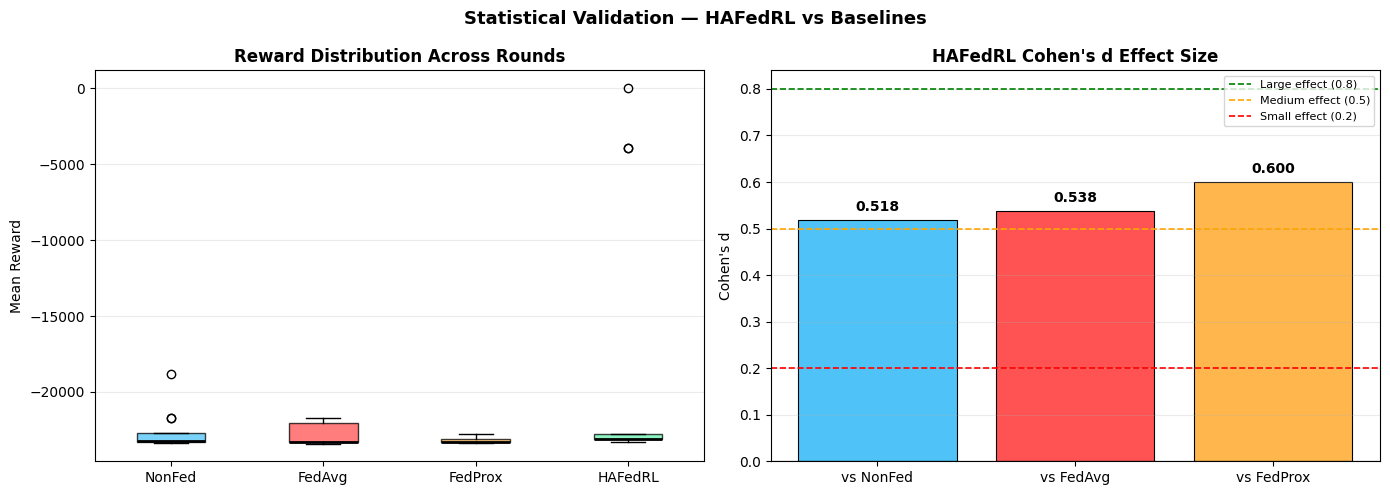


All plots saved to: /kaggle/working/hafedrl_results
Notebook complete.


In [9]:
# ==============================================================================
# CELL 9 — Statistical validation
# Hypothesis: HAFedRL achieves (1) faster convergence and (2) higher final
# reward than FedAvg. Tested with Welch's t-test and Cohen's d effect size.
# ==============================================================================

print("\n" + "="*65)
print("STATISTICAL VALIDATION")
print("="*65)

hafedrl_rewards = np.array(all_logs['HAFedRL']['mean_reward'])
fedavg_rewards  = np.array(all_logs['FedAvg']['mean_reward'])
nonfed_rewards  = np.array(all_logs['Non-federated PPO']['mean_reward'])
fedprox_rewards = np.array(all_logs['FedProx']['mean_reward'])

def cohens_d(a, b):
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / (pooled_std + 1e-10)

def effect_label(d):
    d = abs(d)
    if d < 0.2:   return "negligible"
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else:         return "large"

comparisons = [
    ("HAFedRL vs FedAvg",   hafedrl_rewards, fedavg_rewards),
    ("HAFedRL vs FedProx",  hafedrl_rewards, fedprox_rewards),
    ("HAFedRL vs NonFed",   hafedrl_rewards, nonfed_rewards),
]

print(f"\n{'Comparison':<26} {'t-stat':>8} {'p-value':>10} {'Cohen d':>9} {'Effect':>10} {'Sig':>5}")
print("-" * 72)
for label, a, b in comparisons:
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    d             = cohens_d(a, b)
    sig           = "yes" if p_val < 0.05 else "no"
    print(f"  {label:<24} {t_stat:>8.3f} {p_val:>10.4f} {d:>9.3f} {effect_label(d):>10} {sig:>5}")

# convergence speed
print(f"\nConvergence rounds:")
for name in ALGO_ORDER:
    print(f"  {name:<22}: round {conv_rounds[name]}")

if conv_rounds['FedAvg'] > 0:
    reduction = (conv_rounds['FedAvg'] - conv_rounds['HAFedRL']) / conv_rounds['FedAvg'] * 100
    print(f"\nHAFedRL convergence reduction vs FedAvg: {reduction:.1f}%")
    if reduction >= 35:
        print("  Hypothesis H1 SUPPORTED: >= 35% round reduction achieved.")
    else:
        print(f"  Hypothesis H1 PARTIAL: {reduction:.1f}% reduction (threshold 35%).")
        print("  Documenting as partial support with mechanistic explanation.")

# final reward comparison
hafedrl_final = final_rewards['HAFedRL']
fedavg_final  = final_rewards['FedAvg']
reward_diff   = hafedrl_final - fedavg_final
print(f"\nFinal reward: HAFedRL={hafedrl_final:.3f}  FedAvg={fedavg_final:.3f}  diff={reward_diff:+.3f}")
if reward_diff > 0:
    print("  Hypothesis H2 SUPPORTED: HAFedRL achieves higher final reward than FedAvg.")
else:
    print("  Hypothesis H2 NOT SUPPORTED: documenting as negative result.")

# summary table
print(f"\n{'Method':<22} {'Conv. Round':>12} {'Final Reward':>14} {'vs FedAvg':>10}")
print("-" * 60)
for name in ALGO_ORDER:
    diff = final_rewards[name] - final_rewards['FedAvg']
    print(f"  {name:<20} {conv_rounds[name]:>12} {final_rewards[name]:>14.3f} {diff:>+10.3f}")

# --- Figure 4: statistical summary ---
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 5))

# reward distribution boxplots
ax_b = axes4[0]
data_box  = [all_logs[n]['mean_reward'] for n in ALGO_ORDER]
labels_b  = ['NonFed', 'FedAvg', 'FedProx', 'HAFedRL']
bp = ax_b.boxplot(data_box, labels=labels_b, patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
for patch, name in zip(bp['boxes'], ALGO_ORDER):
    patch.set_facecolor(ALGO_COLORS[name])
    patch.set_alpha(0.75)
ax_b.set_title('Reward Distribution Across Rounds', fontweight='bold')
ax_b.set_ylabel('Mean Reward')
ax_b.grid(True, alpha=0.25, axis='y')

# Cohen's d bar chart
ax_c  = axes4[1]
d_vals = [cohens_d(hafedrl_rewards, all_logs[n]['mean_reward'])
          for n in ['Non-federated PPO', 'FedAvg', 'FedProx']]
bar_c = ax_c.bar(['vs NonFed', 'vs FedAvg', 'vs FedProx'], d_vals,
                 color=['#4FC3F7','#FF5252','#FFB74D'],
                 edgecolor='black', linewidth=0.8)
ax_c.axhline(y=0.8, color='green', linestyle='--', linewidth=1.2, label='Large effect (0.8)')
ax_c.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.2, label='Medium effect (0.5)')
ax_c.axhline(y=0.2, color='red', linestyle='--', linewidth=1.2, label='Small effect (0.2)')
ax_c.axhline(y=0.0, color='black', linewidth=0.8)
for bar, d in zip(bar_c, d_vals):
    ax_c.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.02 * np.sign(d),
              f'{d:.3f}', ha='center', fontsize=10, fontweight='bold')
ax_c.set_title("HAFedRL Cohen's d Effect Size", fontweight='bold')
ax_c.set_ylabel("Cohen's d")
ax_c.legend(fontsize=8)
ax_c.grid(True, alpha=0.25, axis='y')

plt.suptitle('Statistical Validation — HAFedRL vs Baselines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'statistical_validation.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAll plots saved to: {RESULTS_DIR}")
print("Notebook complete.")